# Nyström Projection for Cross-Redshift Embedding Comparison

This notebook projects z=0.95 galaxies into the z=0 embedding space using Nyström extension.

**Key idea:** Instead of computing independent embeddings and aligning with OT, we:
1. Use z=0's MDS embedding as the reference coordinate system
2. Project z=0.95 galaxies into that space based on their similarity to z=0 galaxies

This preserves absolute structural information because all coordinates are in a single reference frame.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from scipy.sparse.linalg import eigsh
import requests

## Load Embedding Data

In [40]:
# Load z=0 embedding (snapshot 99)
data_z0 = np.load('snapshot99_embedding.npz')
embedding_z0 = data_z0['embedding']
original_index_z0 = data_z0['original_index']
sorted_neighbors_z0 = data_z0['sorted_neighbors']

print(f"z=0 embedding shape: {embedding_z0.shape}")
print(f"z=0 sorted neighbors shape: {sorted_neighbors_z0.shape}")

z=0 embedding shape: (17611, 10)
z=0 sorted neighbors shape: (17611, 17611)


In [41]:
# Load z=0.95 embedding (snapshot 51)
data_z1 = np.load('snapshot51_embedding.npz')
embedding_z1 = data_z1['embedding']
original_index_z1 = data_z1['original_index']
sorted_neighbors_z1 = data_z1['sorted_neighbors']

print(f"z=0.95 embedding shape: {embedding_z1.shape}")
print(f"z=0.95 sorted neighbors shape: {sorted_neighbors_z1.shape}")

z=0.95 embedding shape: (15052, 10)
z=0.95 sorted neighbors shape: (15052, 15052)


## Truncate Vectors and Compute z=0 MDS

For Nyström projection to work correctly, D_z0 (within-z0 distances) and C_cross (cross-snapshot distances) must use vectors of the same dimensionality. Since the two snapshots have different numbers of galaxies, we truncate the sorted neighbor vectors to the smaller dimension before computing any distances.

In [42]:
# IMPORTANT: For Nyström projection to work correctly, we need to use the same
# vector dimensions for both D_z0 (within-z0 distances) and C_cross (cross-snapshot distances).
# Since z=0.95 has fewer galaxies (15052) than z=0 (17611), we truncate the sorted
# neighbor vectors to the smaller dimension.

n_z0 = sorted_neighbors_z0.shape[1]
n_z1 = sorted_neighbors_z1.shape[1]
print(f"z=0 sorted neighbors: {n_z0} columns")
print(f"z=0.95 sorted neighbors: {n_z1} columns")

# Truncate to smaller dimension (take the last n_z1 columns, which contain the actual neighbor distances)
if n_z0 >= n_z1:
    sorted_neighbors_z0_truncated = sorted_neighbors_z0[:, -n_z1:]
    print(f"Truncating z=0 sorted neighbors to last {n_z1} columns")
else:
    sorted_neighbors_z0_truncated = sorted_neighbors_z0
    sorted_neighbors_z1 = sorted_neighbors_z1[:, -n_z0:]
    print(f"Truncating z=0.95 sorted neighbors to last {n_z0} columns")

print(f"Truncated z=0 shape: {sorted_neighbors_z0_truncated.shape}")

# Compute similarity distance matrix for z=0 using TRUNCATED vectors
print("\nComputing z=0 similarity distance matrix (using truncated vectors)...")
D_z0 = euclidean_distances(sorted_neighbors_z0_truncated)
print(f"D_z0 shape: {D_z0.shape}")

z=0 sorted neighbors: 17611 columns
z=0.95 sorted neighbors: 15052 columns
Truncating z=0 sorted neighbors to last 15052 columns
Truncated z=0 shape: (17611, 15052)

Computing z=0 similarity distance matrix (using truncated vectors)...
D_z0 shape: (17611, 17611)


In [43]:
# Store means needed for Nyström projection
col_means_z0 = D_z0.mean(axis=0)
grand_mean_z0 = D_z0.mean()

print(f"Column means shape: {col_means_z0.shape}")
print(f"Grand mean: {grand_mean_z0:.4f}")

Column means shape: (17611,)
Grand mean: 22.9668


In [44]:
# Compute MDS embedding via eigendecomposition
print("Computing MDS eigendecomposition...")
n = D_z0.shape[0]
C = np.eye(n) - (1 / n) * np.ones((n, n))
B_z0 = -0.5 * C @ D_z0 @ C

# Get top k eigenvectors/eigenvalues
k = 10  # number of embedding dimensions
eigenvalues, eigenvectors = eigsh(B_z0, k=k, which='LA')

# Sort from largest to smallest
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors shape: {eigenvectors.shape}")

Computing MDS eigendecomposition...
Eigenvalues: [79152.26285876 31361.21290482 15635.3382666   9341.55926785
  6212.4220597   4351.08785881  3136.63677686  2412.49710689
  2054.39075894  1935.96192507]
Eigenvectors shape: (17611, 10)


In [45]:
# Reconstruct z=0 embedding
X_z0 = eigenvectors * np.sqrt(eigenvalues)
print(f"Reconstructed z=0 embedding shape: {X_z0.shape}")

# Align signs with original embedding (eigenvectors are only defined up to a sign flip)
print("\nAligning eigenvector signs with original embedding...")
for dim in range(k):
    corr = np.corrcoef(X_z0[:, dim], embedding_z0[:, dim])[0, 1]
    if corr < 0:
        eigenvectors[:, dim] *= -1
        X_z0[:, dim] *= -1
        print(f"  Flipped sign of dimension {dim+1} (correlation was {corr:.3f})")
    else:
        print(f"  Dimension {dim+1} OK (correlation = {corr:.3f})")

# Verify it matches the loaded embedding
print(f"\nMax difference from loaded embedding: {np.abs(X_z0 - embedding_z0[:, :k]).max():.6f}")

Reconstructed z=0 embedding shape: (17611, 10)

Aligning eigenvector signs with original embedding...
  Flipped sign of dimension 1 (correlation was -1.000)
  Dimension 2 OK (correlation = 1.000)
  Flipped sign of dimension 3 (correlation was -1.000)
  Dimension 4 OK (correlation = 1.000)
  Dimension 5 OK (correlation = 1.000)
  Flipped sign of dimension 6 (correlation was -1.000)
  Dimension 7 OK (correlation = 1.000)
  Flipped sign of dimension 8 (correlation was -1.000)
  Dimension 9 OK (correlation = 1.000)
  Dimension 10 OK (correlation = 1.000)

Max difference from loaded embedding: 0.000000


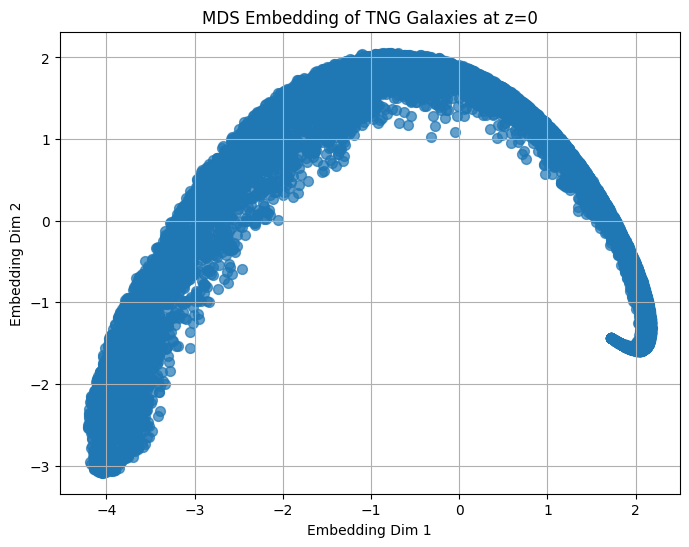

In [46]:
# plot embedding space
plt.figure(figsize=(8, 6))
plt.scatter(X_z0[:, 0], X_z0[:, 1], s=50, alpha=0.7)
plt.xlabel('Embedding Dim 1')
plt.ylabel('Embedding Dim 2')
plt.title('MDS Embedding of TNG Galaxies at z=0')
plt.grid(True)

## Compute Cross-Snapshot Similarity Matrix

This is the similarity distance between each z=0.95 galaxy and all z=0 galaxies, using the same truncated vectors as D_z0.

In [47]:
# Compute cross-snapshot similarity matrix
# Rows: z=0.95 galaxies, Columns: z=0 galaxies
# Using the same truncated vectors as D_z0 for consistency
print("Computing cross-snapshot similarity matrix...")

C_cross = euclidean_distances(sorted_neighbors_z1, sorted_neighbors_z0_truncated)

print(f"Cross-similarity matrix shape: {C_cross.shape}")
print(f"Min: {C_cross.min():.4f}, Max: {C_cross.max():.4f}, Mean: {C_cross.mean():.4f}")

Computing cross-snapshot similarity matrix...


Cross-similarity matrix shape: (15052, 17611)
Min: 0.0000, Max: 78.4443, Mean: 20.5685


## Nyström Projection

Project z=0.95 galaxies into z=0's embedding space.

In [48]:
# Nyström projection formula:
# b_new = -0.5 * (d_new - d_new.mean() - col_means + grand_mean)
# x_new = V.T @ b_new / sqrt(λ)  -->  equivalently: x_new = b_new @ V / sqrt(λ)

# For all z=0.95 galaxies at once:
row_means = C_cross.mean(axis=1, keepdims=True)
B_cross = -0.5 * (C_cross - row_means - col_means_z0 + grand_mean_z0)

# Project onto z=0's eigenvectors
X_z095_projected = B_cross @ eigenvectors / np.sqrt(eigenvalues)

print(f"Projected z=0.95 embedding shape: {X_z095_projected.shape}")

Projected z=0.95 embedding shape: (15052, 10)


## Visualize: z=0 Embedding vs Projected z=0.95

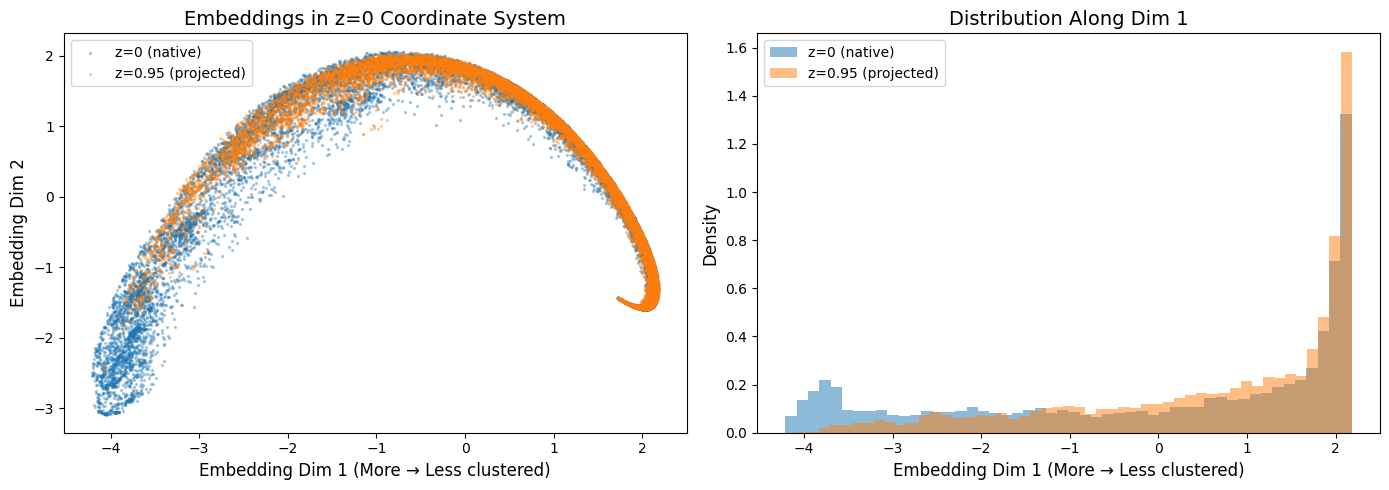

z=0 Dim 1: mean=-0.0000, std=2.1200
z=0.95 projected Dim 1: mean=0.6755, std=1.5787

Systematic shift in Dim 1: 0.6755


In [49]:
# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dim 1 vs Dim 2
ax = axes[0]
ax.scatter(X_z0[:, 0], X_z0[:, 1], s=2, alpha=0.3, label='z=0 (native)')
ax.scatter(X_z095_projected[:, 0], X_z095_projected[:, 1], s=2, alpha=0.3, label='z=0.95 (projected)')
ax.set_xlabel("Embedding Dim 1 (More "+u"\u2192"+" Less clustered)", fontsize=12)
ax.set_ylabel('Embedding Dim 2', fontsize=12)
ax.set_title('Embeddings in z=0 Coordinate System', fontsize=14)
ax.legend()

# Histograms of Dim 1
ax = axes[1]
ax.hist(X_z0[:, 0], bins=50, alpha=0.5, label='z=0 (native)', density=True)
ax.hist(X_z095_projected[:, 0], bins=50, alpha=0.5, label='z=0.95 (projected)', density=True)
ax.set_xlabel("Embedding Dim 1 (More "+u"\u2192"+" Less clustered)", fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution Along Dim 1', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"z=0 Dim 1: mean={X_z0[:, 0].mean():.4f}, std={X_z0[:, 0].std():.4f}")
print(f"z=0.95 projected Dim 1: mean={X_z095_projected[:, 0].mean():.4f}, std={X_z095_projected[:, 0].std():.4f}")
print(f"\nSystematic shift in Dim 1: {X_z095_projected[:, 0].mean() - X_z0[:, 0].mean():.4f}")

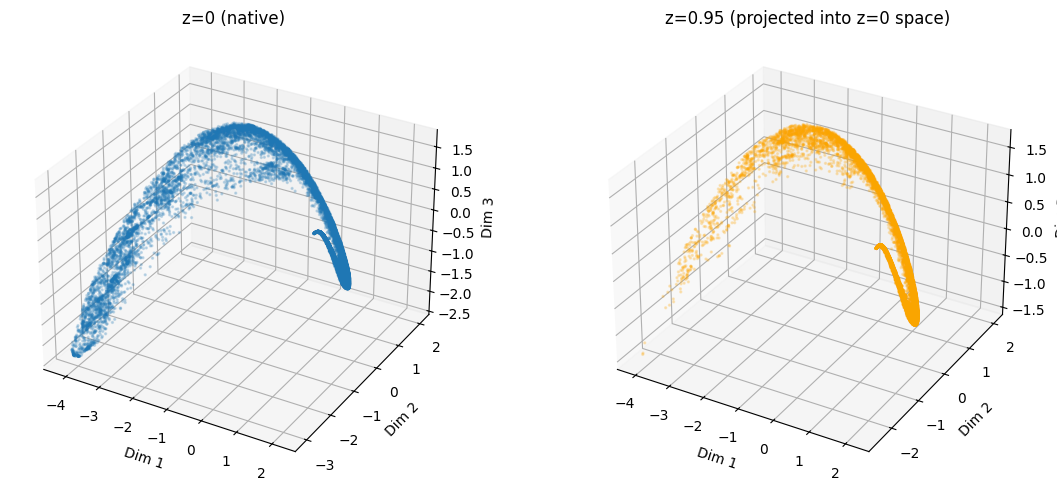

In [50]:
# 3D visualization
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_z0[:, 0], X_z0[:, 1], X_z0[:, 2], s=2, alpha=0.2, label='z=0')
ax1.set_xlabel('Dim 1')
ax1.set_ylabel('Dim 2')
ax1.set_zlabel('Dim 3')
ax1.set_title('z=0 (native)')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_z095_projected[:, 0], X_z095_projected[:, 1], X_z095_projected[:, 2], 
            s=2, alpha=0.2, color='orange', label='z=0.95')
ax2.set_xlabel('Dim 1')
ax2.set_ylabel('Dim 2')
ax2.set_zlabel('Dim 3')
ax2.set_title('z=0.95 (projected into z=0 space)')

plt.tight_layout()
plt.show()

## Track Matched Galaxies Using Merger Trees

In [51]:
# TNG API configuration
API_KEY = "e51de6c190e7b29e4c4d27f191fb6f40"
base_url = "https://www.tng-project.org/api/TNG100-1"
SNAP_Z0 = 99
SNAP_Z095 = 51

In [52]:
def find_progenitor_at_snapshot_api(subfind_id, snap_descendant, snap_target):
    """
    Find the main progenitor of a galaxy at a target snapshot using TNG web API.
    """
    url = f"{base_url}/snapshots/{snap_descendant}/subhalos/{subfind_id}/sublink/simple.json"
    headers = {"api-key": API_KEY}
    
    try:
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            return None
        if 'application/json' not in response.headers.get('Content-Type', ''):
            return None
        
        data = response.json()
        if 'Main' not in data:
            return None
        
        main = data['Main']
        if not isinstance(main, list) or len(main) == 0:
            return None
        
        snaps = [entry[0] for entry in main]
        subfind_ids = [entry[1] for entry in main]
        
        if snap_target not in snaps:
            return None
        
        idx = snaps.index(snap_target)
        return int(subfind_ids[idx])
    
    except Exception:
        return None

In [53]:
# Look up progenitors for sample galaxies
NUM_SAMPLE = 1000

print(f"Looking up progenitors for {NUM_SAMPLE} galaxies...")

# Create lookup table for z=0.95 SubfindIDs -> embedding indices
subfind_to_idx_z1 = {int(sid): idx for idx, sid in enumerate(original_index_z1)}

matched_pairs = []
sample_indices = np.random.choice(len(original_index_z0), NUM_SAMPLE, replace=False)

for i in sample_indices:
    subfind_z0 = int(original_index_z0[i])
    prog_subfind = find_progenitor_at_snapshot_api(subfind_z0, SNAP_Z0, SNAP_Z095)
    
    if prog_subfind is None:
        continue
    
    if prog_subfind not in subfind_to_idx_z1:
        continue
    
    idx_z1 = subfind_to_idx_z1[prog_subfind]
    
    matched_pairs.append({
        'idx_z0': i,
        'idx_z1': idx_z1,
        'subfind_z0': subfind_z0,
        'subfind_z1': prog_subfind
    })

print(f"Successfully matched {len(matched_pairs)} galaxy pairs")

# Extract indices
idx_z0 = np.array([p['idx_z0'] for p in matched_pairs])
idx_z1 = np.array([p['idx_z1'] for p in matched_pairs])

Looking up progenitors for 1000 galaxies...
Successfully matched 610 galaxy pairs


## Compute Displacement in Shared Coordinate System

In [70]:
# Get coordinates for matched pairs
# Both are now in z=0's coordinate system!
coords_z0 = X_z0[idx_z0]
coords_z095_projected = X_z095_projected[idx_z1]

# Compute displacement (z=0 position - z=0.95 position, both in z=0 space)
displacement = coords_z0 - coords_z095_projected
displacement_magnitude = np.linalg.norm(displacement, axis=1)

print(f"Number of matched pairs: {len(displacement)}")
print(f"\nDisplacement statistics:")
print(f"  Dim 1: mean={displacement[:, 0].mean():.4f}, std={displacement[:, 0].std():.4f}")
print(f"  Dim 2: mean={displacement[:, 1].mean():.4f}, std={displacement[:, 1].std():.4f}")
print(f"  Dim 3: mean={displacement[:, 2].mean():.4f}, std={displacement[:, 2].std():.4f}")
print(f"  Magnitude: mean={displacement_magnitude.mean():.4f}, std={displacement_magnitude.std():.4f}")

Number of matched pairs: 610

Displacement statistics:
  Dim 1: mean=-0.9361, std=1.3473
  Dim 2: mean=-0.1524, std=1.3065
  Dim 3: mean=-0.0029, std=1.0965
  Magnitude: mean=2.3708, std=1.6169


In [71]:
# Check if displacement is systematically positive or negative
print("Displacement direction analysis:")
for dim in range(3):
    n_positive = np.sum(displacement[:, dim] > 0)
    n_negative = np.sum(displacement[:, dim] < 0)
    mean_disp = displacement[:, dim].mean()
    print(f"  Dim {dim+1}: {n_positive} positive, {n_negative} negative, mean={mean_disp:.4f}")

Displacement direction analysis:
  Dim 1: 154 positive, 456 negative, mean=-0.9361
  Dim 2: 307 positive, 303 negative, mean=-0.1524
  Dim 3: 296 positive, 314 negative, mean=-0.0029


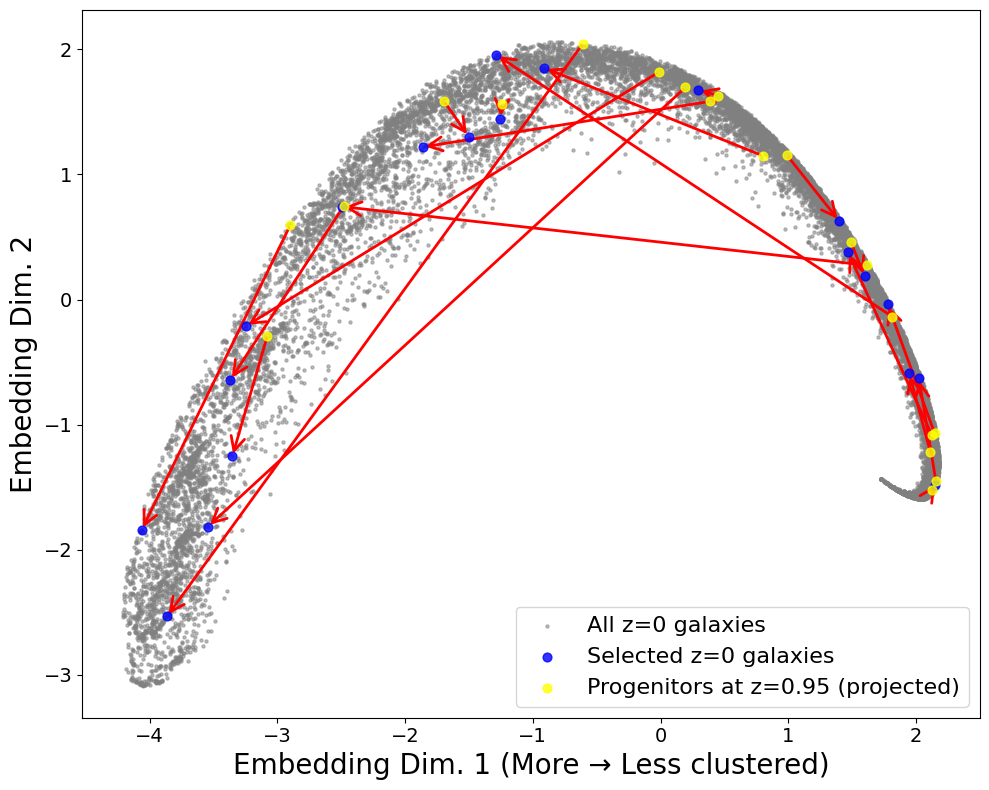

In [72]:
# Visualize displacement vectors (subset of 20 galaxies)
fig, ax = plt.subplots(figsize=(10, 8))

# Select 20 random galaxies to plot
n_plot = 20
plot_idx = np.random.choice(len(coords_z0), n_plot, replace=False)

# Plot all z=0 galaxies as background
ax.scatter(X_z0[:, 0], X_z0[:, 1], s=5, alpha=0.5, c='gray', label='All z=0 galaxies')

# Plot matched galaxies (subset)
ax.scatter(coords_z0[plot_idx, 0], coords_z0[plot_idx, 1], s=40, alpha=0.8, c='blue', label='Selected z=0 galaxies', zorder=5)
ax.scatter(coords_z095_projected[plot_idx, 0], coords_z095_projected[plot_idx, 1], s=40, alpha=0.8, c='yellow', 
           label='Progenitors at z=0.95 (projected)', zorder=5)

# Draw arrows from z=0.95 to z=0
for i in plot_idx:
    ax.annotate('', xy=coords_z0[i, :2], xytext=coords_z095_projected[i, :2],
                arrowprops=dict(arrowstyle='->', color='red', alpha=1, lw=2, mutation_scale=25))

ax.set_xlabel('Embedding Dim. 1 (More '+u"\u2192"+" Less clustered)", fontsize=20)
ax.set_ylabel('Embedding Dim. 2', fontsize=20)
# ax.set_title(f'Galaxy Evolution in z=0 Embedding Space ({n_plot} pairs)', fontsize=14)
ax.legend(fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

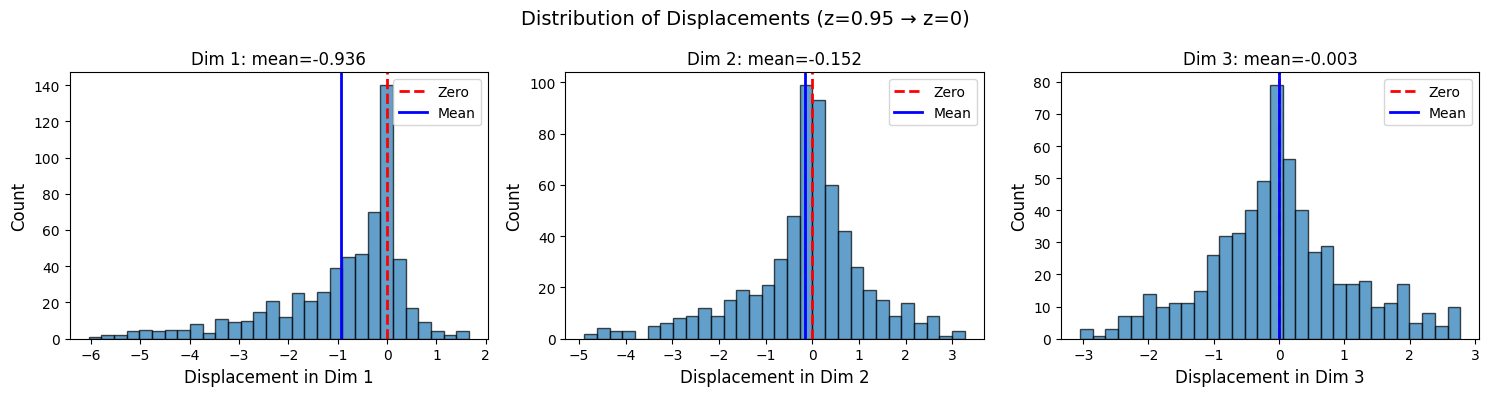

In [73]:
# Histogram of displacements along each dimension
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for dim in range(3):
    ax = axes[dim]
    ax.hist(displacement[:, dim], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
    ax.axvline(displacement[:, dim].mean(), color='blue', linestyle='-', linewidth=2, label='Mean')
    ax.set_xlabel(f'Displacement in Dim {dim+1}', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Dim {dim+1}: mean={displacement[:, dim].mean():.3f}', fontsize=12)
    ax.legend()

plt.suptitle('Distribution of Displacements (z=0.95 → z=0)', fontsize=14)
plt.tight_layout()
plt.show()

## Fetch Galaxy Properties and Correlate with Displacement

In [93]:
# Fetch properties at z=0.95
print("Fetching galaxy properties from TNG API (z=0.95)...")

subfind_z1_list = [p['subfind_z1'] for p in matched_pairs]

sfr_z095 = []
mass_z095 = []
stellar_mass_z095 = []
metallicity_z095 = []
headers = {"api-key": API_KEY}

for i, subfind_id in enumerate(subfind_z1_list):
    url = f"{base_url}/snapshots/{SNAP_Z095}/subhalos/{int(subfind_id)}"
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200 and 'application/json' in response.headers.get('Content-Type', ''):
        data = response.json()
        sfr_z095.append(data.get('sfr', np.nan))
        mass_z095.append(data.get('mass', np.nan))
        metallicity_z095.append(data.get('starmetallicity', np.nan))
        stellar_mass_z095.append(data.get('mass_stars', np.nan))
    else:
        sfr_z095.append(np.nan)
        mass_z095.append(np.nan)
        metallicity_z095.append(np.nan)
        stellar_mass_z095.append(np.nan)

sfr_z095 = np.array(sfr_z095)
mass_z095 = np.array(mass_z095)
metallicity_z095 = np.array(metallicity_z095)
stellar_mass_z095 = np.array(stellar_mass_z095)

print(f"Fetched properties for {np.sum(~np.isnan(sfr_z095))} galaxies")

Fetching galaxy properties from TNG API (z=0.95)...
Fetched properties for 610 galaxies


In [94]:
# Fetch properties at z=0
print("Fetching galaxy properties from TNG API (z=0)...")

subfind_z0_list = [p['subfind_z0'] for p in matched_pairs]

sfr_z0 = []
mass_z0 = []
metallicity_z0 = []
stellar_mass_z0 = []

for i, subfind_id in enumerate(subfind_z0_list):
    url = f"{base_url}/snapshots/{SNAP_Z0}/subhalos/{int(subfind_id)}"
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200 and 'application/json' in response.headers.get('Content-Type', ''):
        data = response.json()
        sfr_z0.append(data.get('sfr', np.nan))
        mass_z0.append(data.get('mass', np.nan))
        metallicity_z0.append(data.get('starmetallicity', np.nan))
        stellar_mass_z0.append(data.get('mass_stars', np.nan))
    else:
        sfr_z0.append(np.nan)
        mass_z0.append(np.nan)
        metallicity_z0.append(np.nan)
        stellar_mass_z0.append(np.nan)

sfr_z0 = np.array(sfr_z0)
mass_z0 = np.array(mass_z0)
metallicity_z0 = np.array(metallicity_z0)
stellar_mass_z0 = np.array(stellar_mass_z0)

print(f"Fetched properties for {np.sum(~np.isnan(sfr_z0))} galaxies")

Fetching galaxy properties from TNG API (z=0)...
Fetched properties for 610 galaxies


In [95]:
stellar_mass_z0

array([ 3.04503 ,  1.17742 ,  2.72682 ,  2.98599 ,  0.22021 ,  0.318973,
        0.301286,  5.39856 ,  0.958161,  1.1364  ,  0.807868,  0.626629,
        0.591966,  1.847   ,  0.123067,  0.445587,  0.696858,  0.316778,
        0.236361,  0.261207,  4.61552 ,  0.314272,  0.38134 ,  0.160907,
        0.204873,  0.163941,  2.92631 ,  1.37142 ,  0.846759,  0.475761,
        2.87301 ,  1.12547 ,  9.43951 ,  3.04198 ,  1.9213  ,  0.298497,
        2.93882 ,  0.759705,  0.867738,  5.37979 ,  2.02904 ,  2.09671 ,
        0.285007,  0.13518 ,  0.170316,  2.5518  ,  0.539542,  0.593445,
        0.395337,  0.62323 ,  0.162934,  1.01847 ,  3.0469  ,  0.985305,
        0.539401,  2.47386 ,  0.72692 ,  1.15803 ,  0.923455,  0.300022,
        0.775427,  2.05911 ,  4.63521 ,  4.29696 ,  0.564165,  1.0144  ,
        0.520025,  4.73058 ,  4.5012  ,  0.782049,  1.61121 ,  0.603294,
        0.856713,  0.600102,  0.662097,  0.26964 ,  1.23529 ,  0.458185,
        0.28495 ,  0.353839,  3.86133 ,  0.931113, 

In [96]:
# Compute property changes
delta_sfr = sfr_z0 - sfr_z095
# delta_mass = mass_z0 - mass_z095
delta_mass = stellar_mass_z0 - stellar_mass_z095

delta_metallicity = metallicity_z0 - metallicity_z095
log_mass_ratio = np.log10(stellar_mass_z0 / stellar_mass_z095)

print("Change in galaxy properties (z=0.95 → z=0):")
print(f"  Δ SFR: mean={np.nanmean(delta_sfr):.3f}, std={np.nanstd(delta_sfr):.3f}")
print(f"  log(M_z0/M_z095): mean={np.nanmean(log_mass_ratio):.3f}, std={np.nanstd(log_mass_ratio):.3f}")
print(f"  Δ Z*: mean={np.nanmean(delta_metallicity):.4f}, std={np.nanstd(delta_metallicity):.4f}")

Change in galaxy properties (z=0.95 → z=0):
  Δ SFR: mean=-2.616, std=4.923
  log(M_z0/M_z095): mean=0.282, std=0.264
  Δ Z*: mean=0.0050, std=0.0041


In [103]:
sum(delta_mass < 0) / len(delta_mass)

np.float64(0.1360655737704918)

(array([  1.,  10., 380., 143.,  33.,  18.,   5.,   7.,   1.,   5.,   0.,
          1.,   1.,   2.,   1.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([-3.25801 , -1.971303, -0.684596,  0.602111,  1.888818,  3.175525,
         4.462232,  5.748939,  7.035646,  8.322353,  9.60906 , 10.895767,
        12.182474, 13.469181, 14.755888, 16.042595, 17.329302, 18.616009,
        19.902716, 21.189423, 22.47613 , 23.762837, 25.049544, 26.336251,
        27.622958, 28.909665, 30.196372, 31.483079, 32.769786, 34.056493,
        35.3432  ]),
 <BarContainer object of 30 artists>)

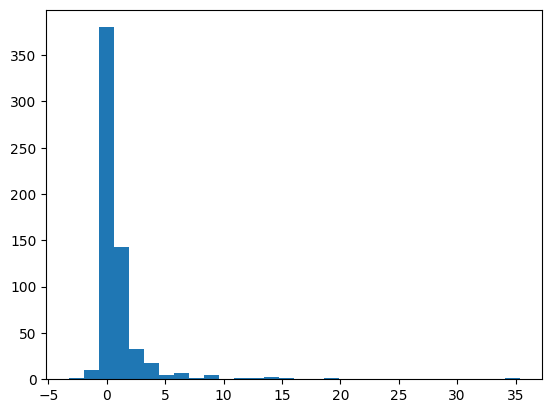

In [101]:
plt.hist(delta_mass, bins=30)

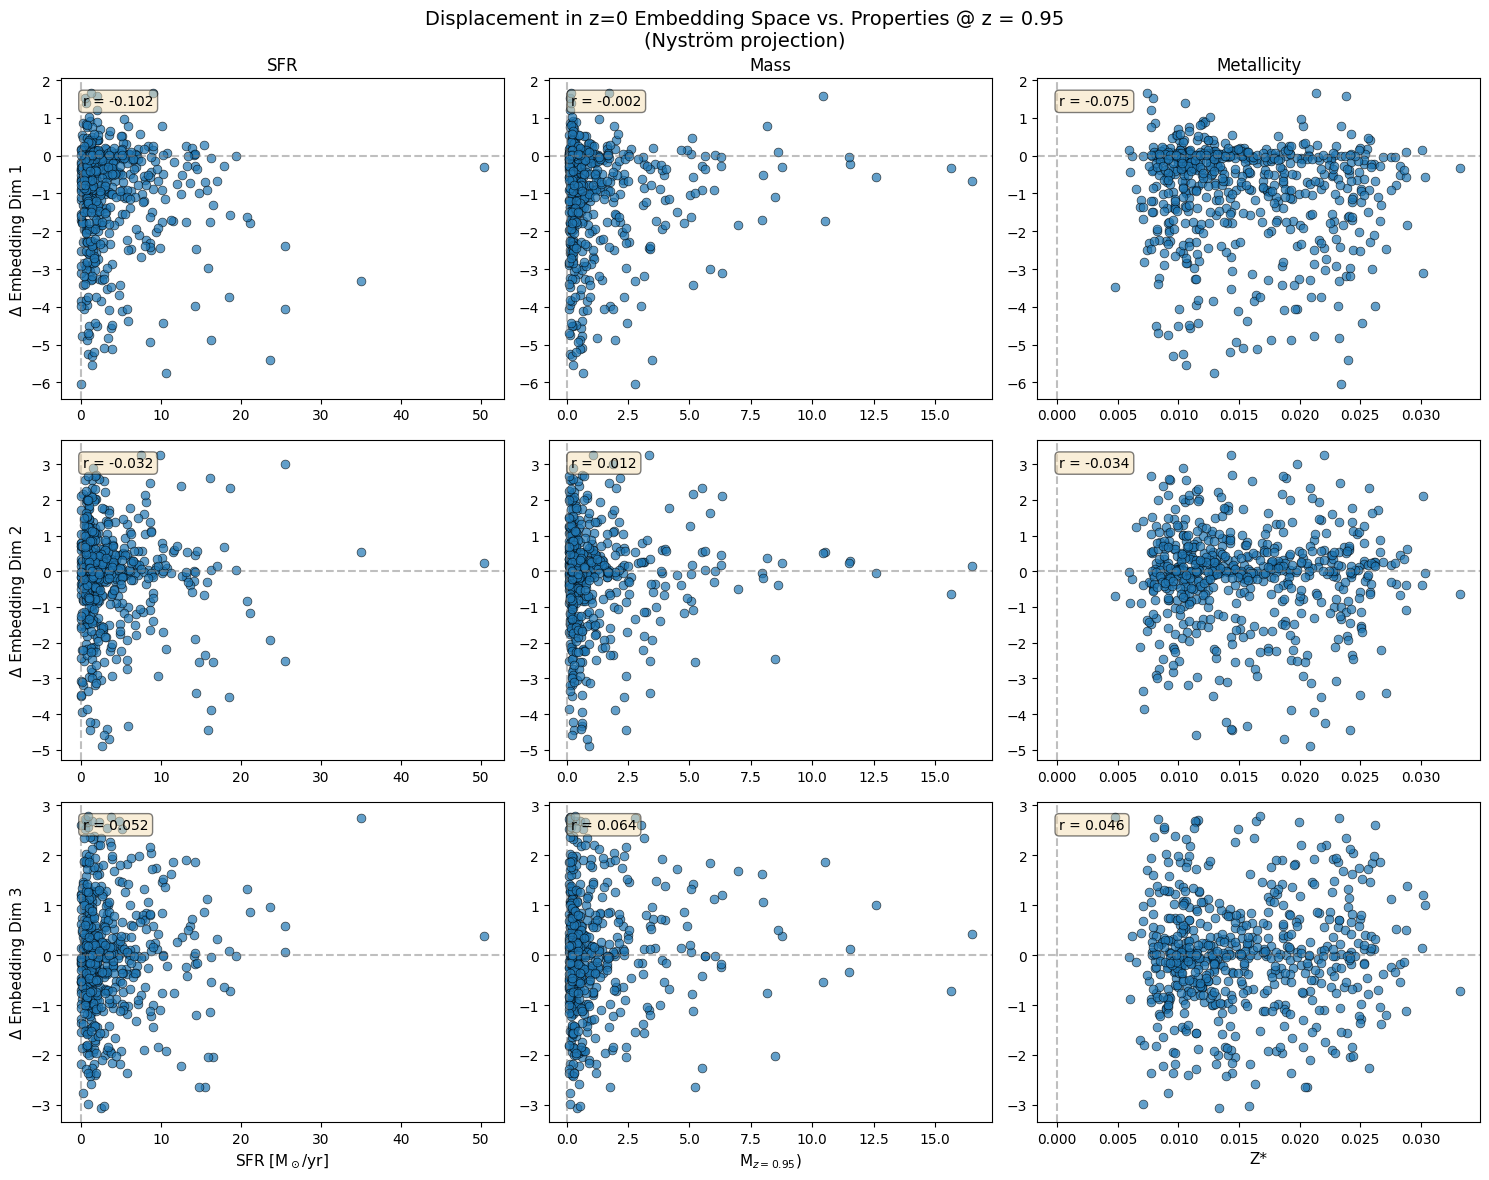

In [152]:
# Plot displacement vs change in properties
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

properties = [
    ('SFR', sfr_z095, 'SFR [M$_\odot$/yr]'),
    ('Mass', stellar_mass_z095, 'M$_{z=0.95}$)'),
    ('Metallicity', metallicity_z095, 'Z*')
]

for row, dim in enumerate([0, 1, 2]):
    disp_dim = displacement[:, dim]
    
    for col, (name, values, xlabel) in enumerate(properties):
        ax = axes[row, col]
        valid = ~np.isnan(values) & ~np.isinf(values)
        
        ax.scatter(values[valid], disp_dim[valid], s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        
        ax.set_xlabel(xlabel if row == 2 else '', fontsize=11)
        ax.set_ylabel(f'Δ Embedding Dim {dim+1}' if col == 0 else '', fontsize=11)
        
        if row == 0:
            ax.set_title(name, fontsize=12)
        
        # Correlation coefficient
        if np.sum(valid) > 2:
            corr = np.corrcoef(values[valid], disp_dim[valid])[0, 1]
            ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Displacement in z=0 Embedding Space vs. Properties @ z = 0.95\n(Nyström projection)', fontsize=14)
plt.tight_layout()
plt.show()

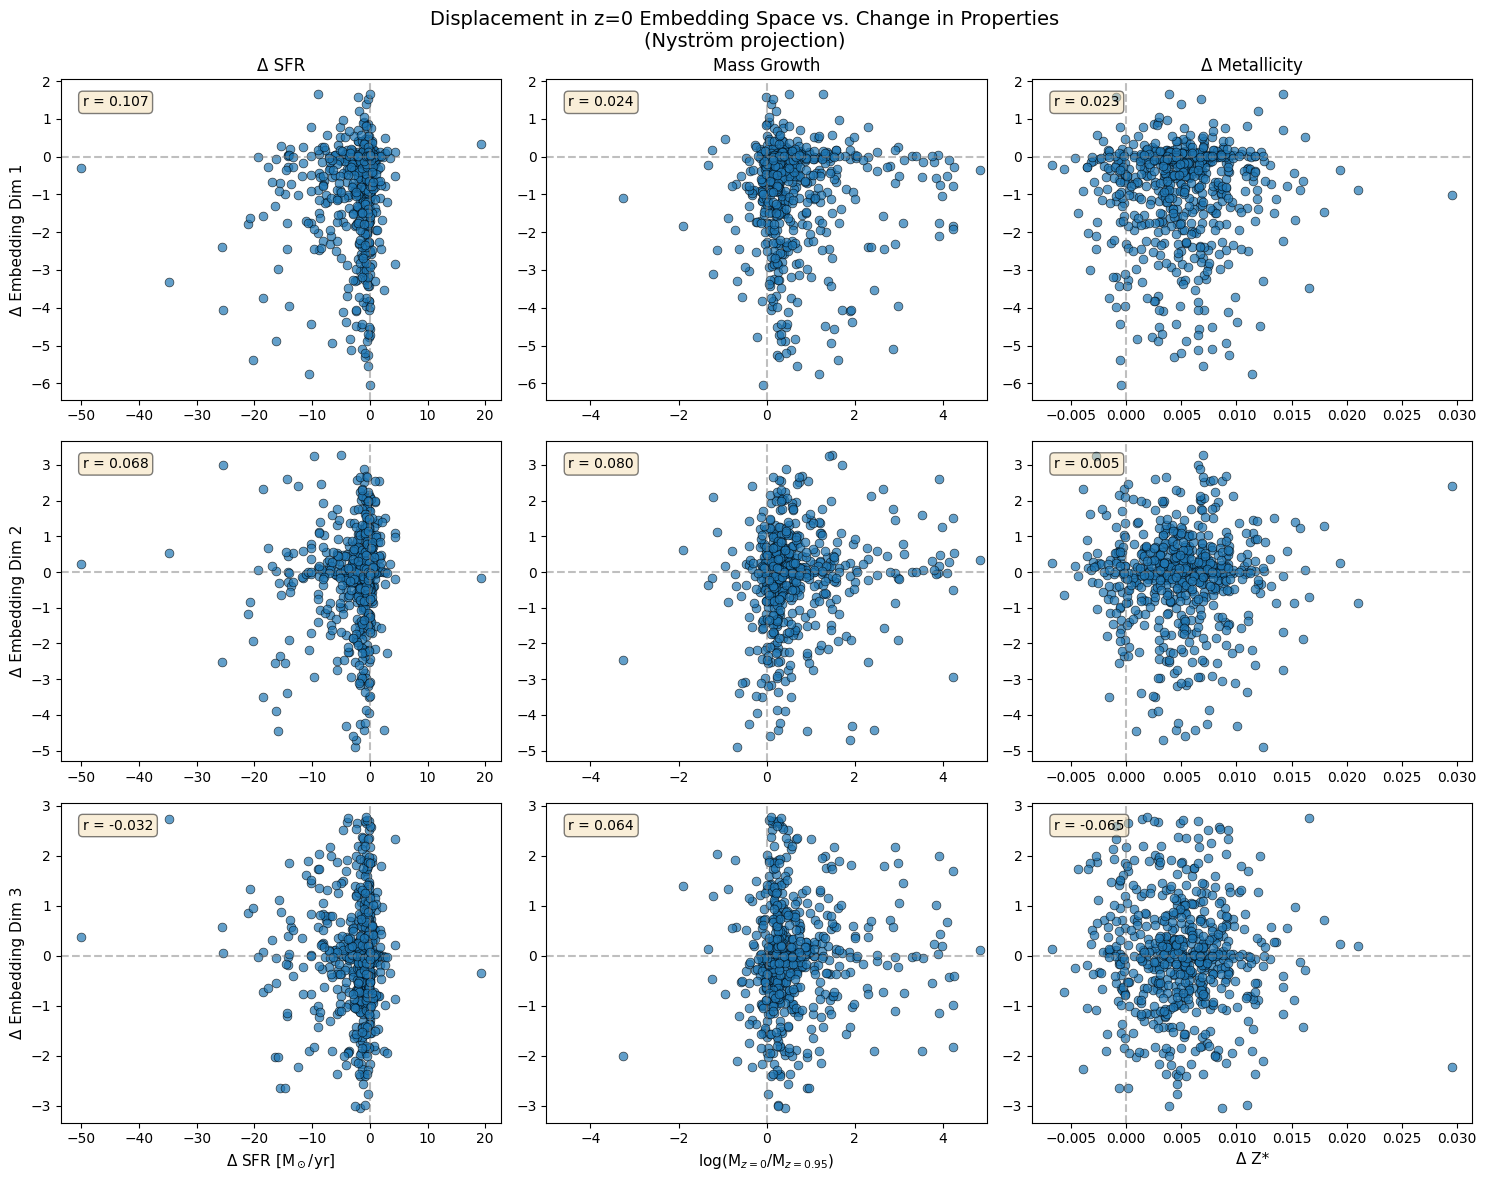

In [150]:
# Plot displacement vs change in properties
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

properties = [
    ('Δ SFR', delta_sfr, 'Δ SFR [M$_\odot$/yr]'),
    ('Mass Growth', delta_mass, 'log(M$_{z=0}$/M$_{z=0.95}$)'),
    ('Δ Metallicity', delta_metallicity, 'Δ Z*')
]

for row, dim in enumerate([0, 1, 2]):
    disp_dim = displacement[:, dim]
    
    for col, (name, values, xlabel) in enumerate(properties):
        ax = axes[row, col]
        valid = ~np.isnan(values) & ~np.isinf(values)
        
        ax.scatter(values[valid], disp_dim[valid], s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        
        ax.set_xlabel(xlabel if row == 2 else '', fontsize=11)
        ax.set_ylabel(f'Δ Embedding Dim {dim+1}' if col == 0 else '', fontsize=11)
        
        if row == 0:
            ax.set_title(name, fontsize=12)
        if col==1:
            ax.set_xlim(-5, 5)
        
        # Correlation coefficient
        if np.sum(valid) > 2:
            corr = np.corrcoef(values[valid], disp_dim[valid])[0, 1]
            ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Displacement in z=0 Embedding Space vs. Change in Properties\n(Nyström projection)', fontsize=14)
plt.tight_layout()
plt.show()

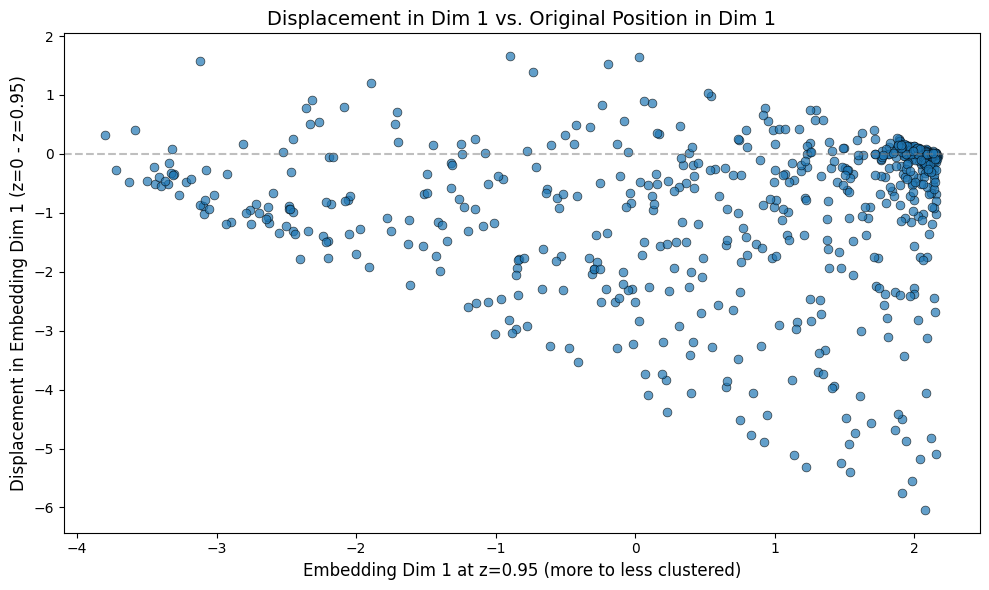

In [107]:
# Plot original embedding dim 1 value vs. delta embedding dim 1
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(coords_z095_projected[:, 0], displacement[:, 0], s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Embedding Dim 1 at z=0.95 (more to less clustered)', fontsize=12)
ax.set_ylabel('Displacement in Embedding Dim 1 (z=0 - z=0.95)', fontsize=12)
ax.set_title('Displacement in Dim 1 vs. Original Position in Dim 1', fontsize=14)
plt.tight_layout()
plt.show()

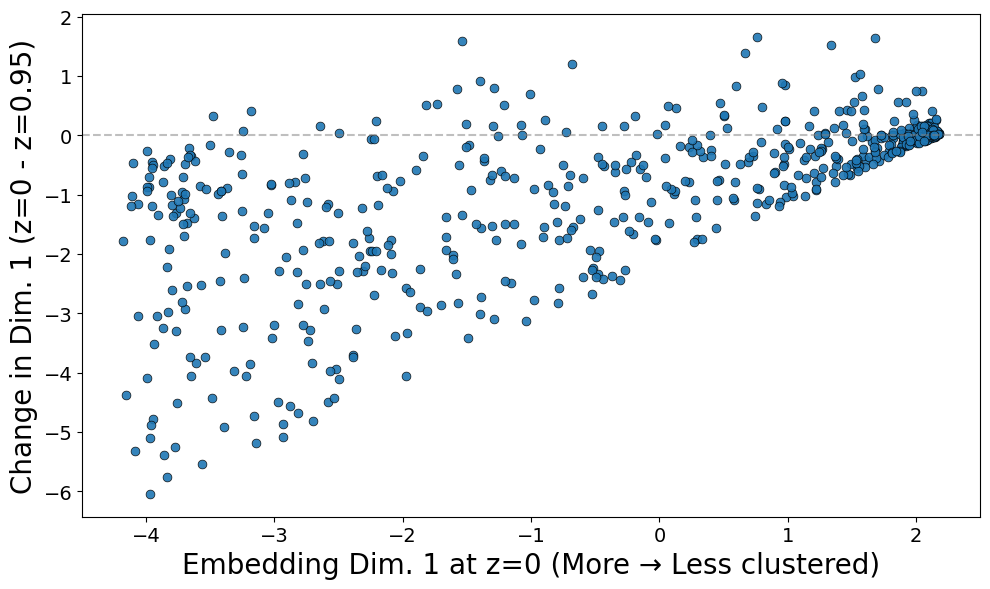

In [193]:
# Plot original embedding dim 1 value vs. delta embedding dim 1
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(coords_z0[:, 0], displacement[:, 0], s=40, alpha=0.9, edgecolors='k', linewidths=0.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Embedding Dim. 1 at z=0 (More '+u"\u2192"+" Less clustered)", fontsize=20)
ax.set_ylabel('Change in Dim. 1 (z=0 - z=0.95)', fontsize=20)
# ax.set_title('Displacement in Dim 1 vs. Original Position in Dim 1', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

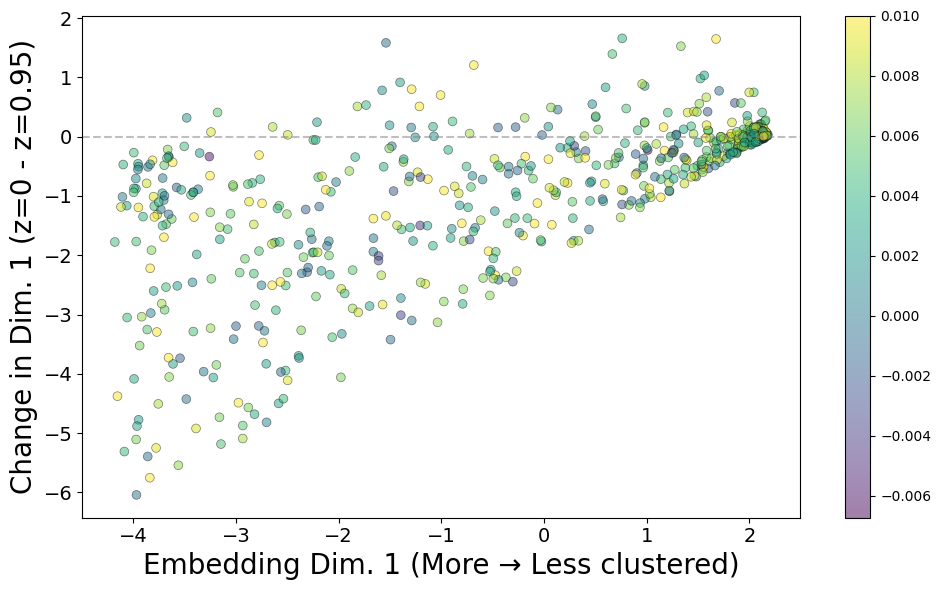

In [156]:
# Plot original embedding dim 1 value vs. delta embedding dim 1
fig, ax = plt.subplots(figsize=(10, 6))
s = ax.scatter(coords_z0[:, 0], displacement[:, 0], s=40, alpha=0.5, edgecolors='k', linewidths=0.5,
               c = delta_metallicity, vmax=0.01)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Embedding Dim. 1 (More '+u"\u2192"+" Less clustered)", fontsize=20)
ax.set_ylabel('Change in Dim. 1 (z=0 - z=0.95)', fontsize=20)
plt.colorbar(s)
# ax.set_title('Displacement in Dim 1 vs. Original Position in Dim 1', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

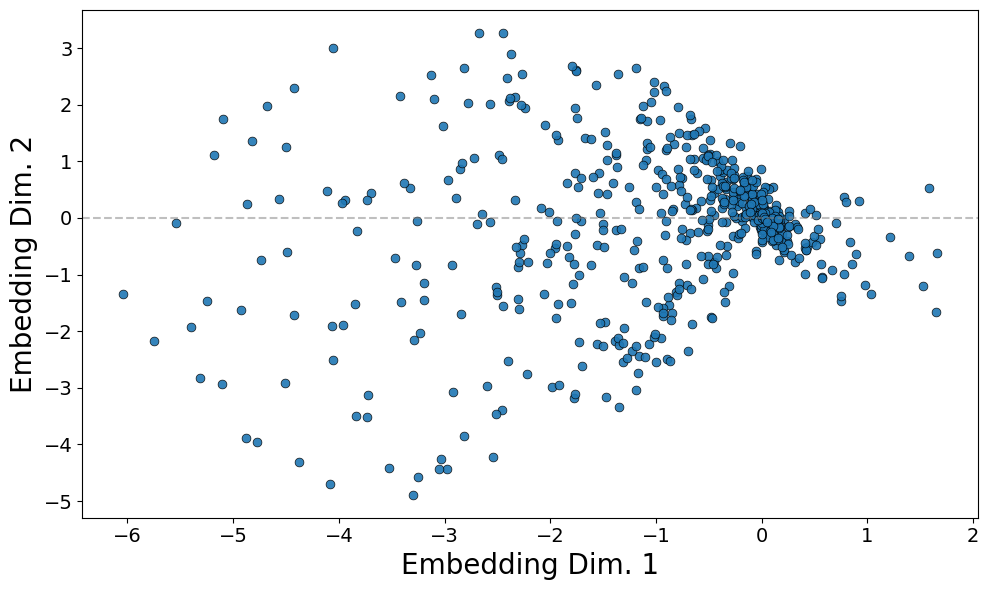

In [133]:
# Plot original embedding dim 1 value vs. delta embedding dim 1
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(displacement[:, 0], displacement[:, 1], s=40, alpha=0.9, edgecolors='k', linewidths=0.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Embedding Dim. 1', fontsize=20)
ax.set_ylabel('Embedding Dim. 2', fontsize=20)
# ax.set_title('Displacement in Dim 1 vs. Original Position in Dim 1', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

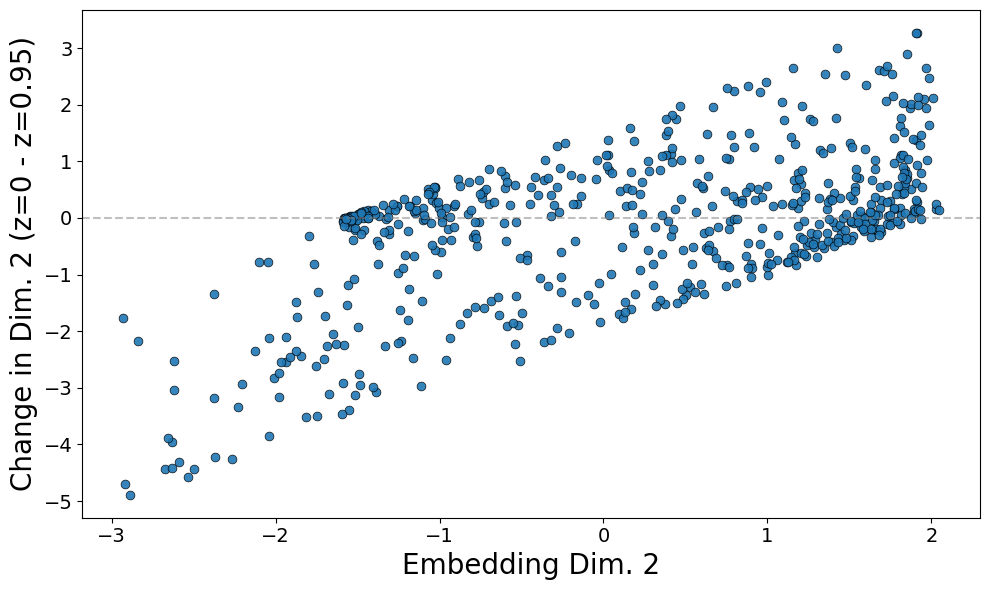

In [131]:
# Plot original embedding dim 1 value vs. delta embedding dim 1
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(coords_z0[:, 1], displacement[:, 1], s=40, alpha=0.9, edgecolors='k', linewidths=0.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Embedding Dim. 2', fontsize=20)
ax.set_ylabel('Change in Dim. 2 (z=0 - z=0.95)', fontsize=20)
# ax.set_title('Displacement in Dim 1 vs. Original Position in Dim 1', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

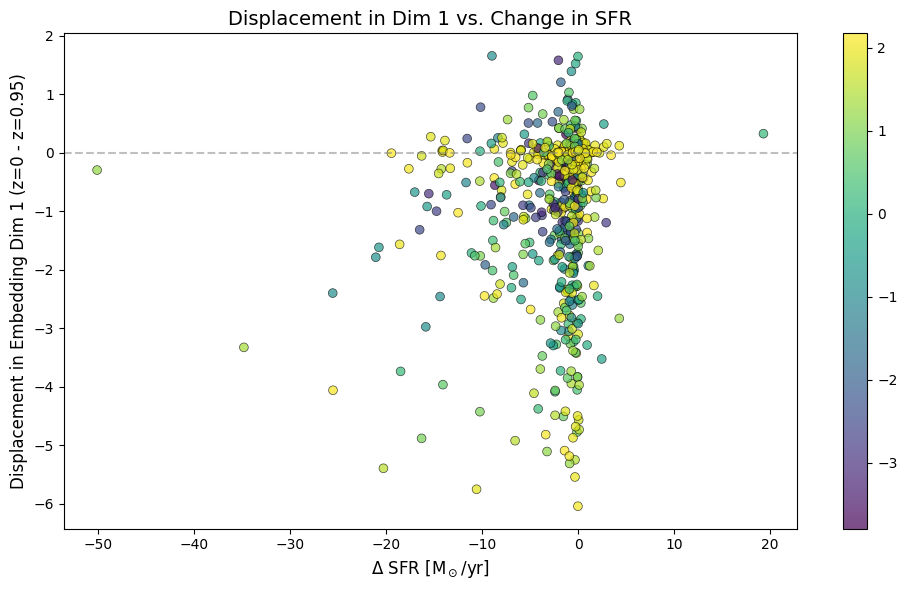

In [109]:
# plot displacement in dim 1 vs. change in sfr
fig, ax = plt.subplots(figsize=(10, 6))
valid = ~np.isnan(delta_sfr) & ~np.isinf(delta_sfr)
s = ax.scatter(delta_sfr[valid], displacement[:, 0][valid], s=40, alpha=0.7, edgecolors='k', linewidths=0.5, c =coords_z095_projected[:, 0][valid], cmap='viridis')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Δ SFR [M$_\odot$/yr]', fontsize=12)
ax.set_ylabel('Displacement in Embedding Dim 1 (z=0 - z=0.95)', fontsize=12)   
ax.set_title('Displacement in Dim 1 vs. Change in SFR', fontsize=14)
plt.colorbar(s)
plt.tight_layout()
plt.show()

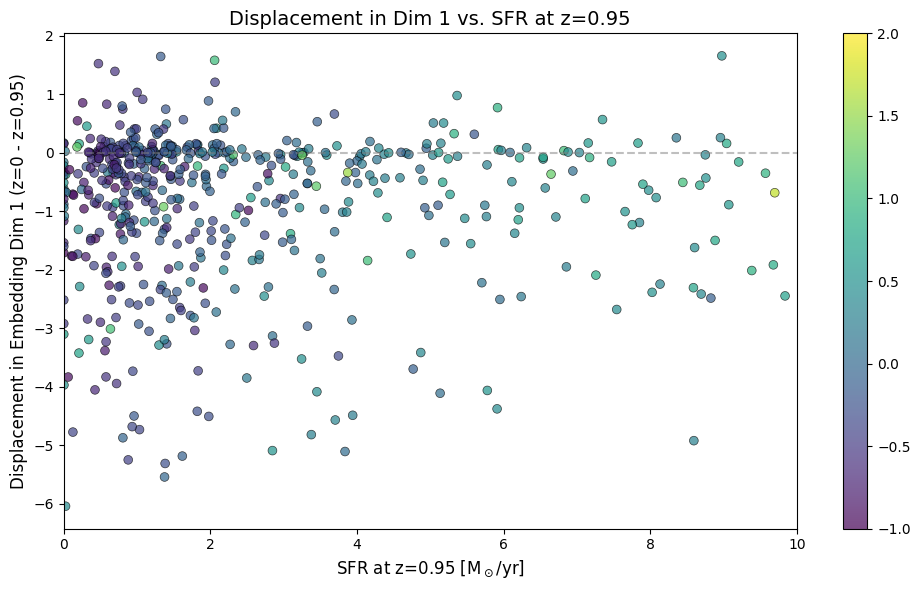

In [190]:
# plot displacement in dim 1 vs. sfr @ z=0.95
fig, ax = plt.subplots(figsize=(10, 6))
valid = ~np.isnan(sfr_z095) & ~np.isinf(sfr_z095)
s = ax.scatter(sfr_z095[valid], displacement[:, 0][valid], 
               s=40, alpha=0.7, edgecolors='k', linewidths=0.5, 
               c = np.log10(stellar_mass_z0[valid]), cmap='viridis', vmin=-1, vmax=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('SFR at z=0.95 [M$_\odot$/yr]', fontsize=12)
ax.set_ylabel('Displacement in Embedding Dim 1 (z=0 - z=0.95)', fontsize=12)
ax.set_title('Displacement in Dim 1 vs. SFR at z=0.95', fontsize=14)
ax.set_xlim(0, 10)
plt.colorbar(s)
plt.tight_layout()
plt.show()

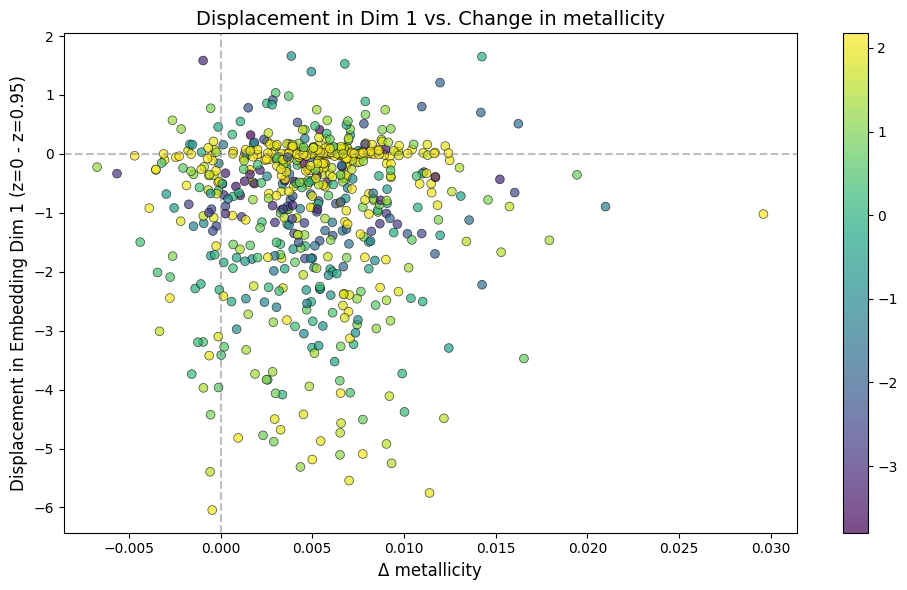

In [110]:
# plot displacement in dim 1 vs. change in sfr
fig, ax = plt.subplots(figsize=(10, 6))
valid = ~np.isnan(delta_metallicity) & ~np.isinf(delta_metallicity)
s = ax.scatter(delta_metallicity[valid], displacement[:, 0][valid], s=40, alpha=0.7, edgecolors='k', linewidths=0.5, c =coords_z095_projected[:, 0][valid], cmap='viridis')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Δ metallicity', fontsize=12)
ax.set_ylabel('Displacement in Embedding Dim 1 (z=0 - z=0.95)', fontsize=12)   
ax.set_title('Displacement in Dim 1 vs. Change in metallicity', fontsize=14)
plt.colorbar(s)
plt.tight_layout()
plt.show()

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_74847/1154239613.py:4: RuntimeWarning: divide by zero encountered in log10
  log_sfr = np.log10(sfr_z0[valid])


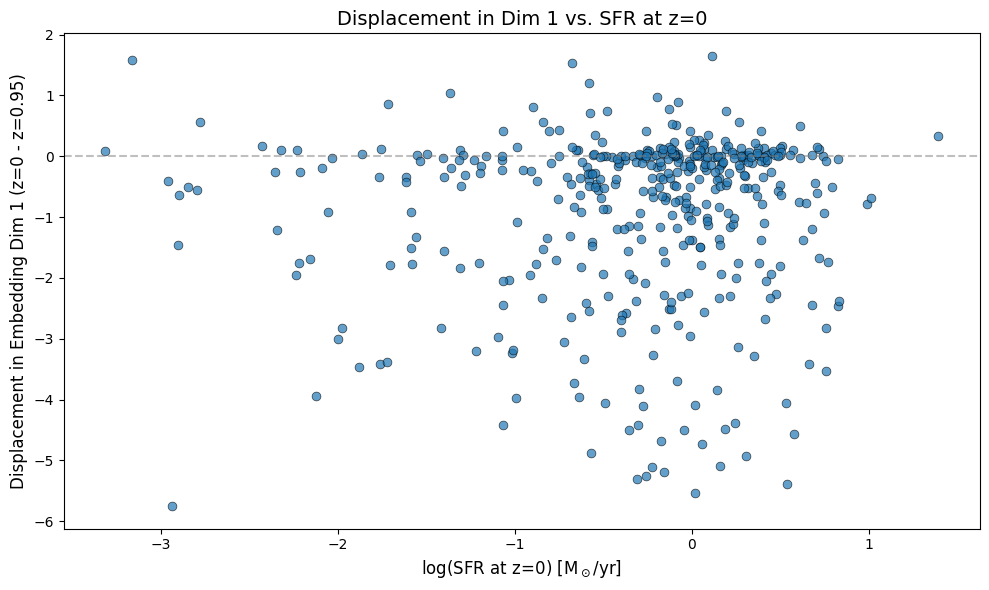

In [111]:
# plot displacement in dim 1 vs. SFR at z=0
fig, ax = plt.subplots(figsize=(10, 6))
valid = ~np.isnan(sfr_z0) & ~np.isinf(sfr_z0)
log_sfr = np.log10(sfr_z0[valid])
disp_valid = displacement[:, 0][valid]
ax.scatter(log_sfr, disp_valid, s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('log(SFR at z=0) [M$_\odot$/yr]', fontsize=12)
ax.set_ylabel('Displacement in Embedding Dim 1 (z=0 - z=0.95)', fontsize=12)   
ax.set_title('Displacement in Dim 1 vs. SFR at z=0', fontsize=14)
plt.tight_layout()
plt.show()


/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_74847/212112272.py:4: RuntimeWarning: divide by zero encountered in log10
  log_sfr = np.log10(sfr_z095[valid])


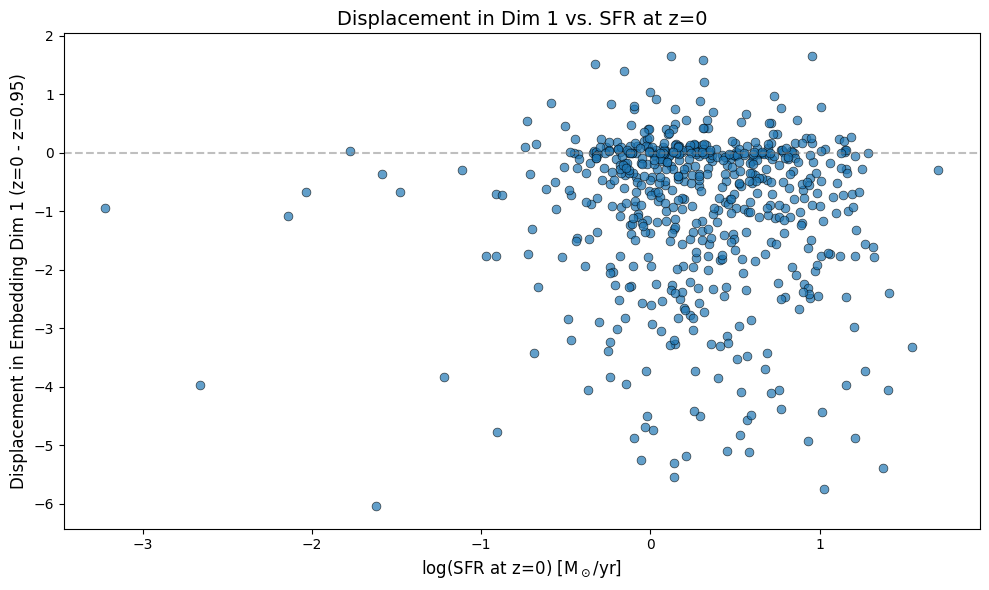

In [ ]:
# plot displacement in dim 1 vs. SFR at z=0.95
fig, ax = plt.subplots(figsize=(10, 6))
valid = ~np.isnan(sfr_z095) & ~np.isinf(sfr_z095)
log_sfr = np.log10(sfr_z095[valid])
disp_valid = displacement[:, 0][valid]
ax.scatter(log_sfr, disp_valid, s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('log(SFR at z=0) [M$_\odot$/yr]', fontsize=12)
ax.set_ylabel('Displacement in Embedding Dim 1 (z=0 - z=0.95)', fontsize=12)   
ax.set_title('Displacement in Dim 1 vs. SFR at z=0', fontsize=14)
plt.tight_layout()
plt.show()


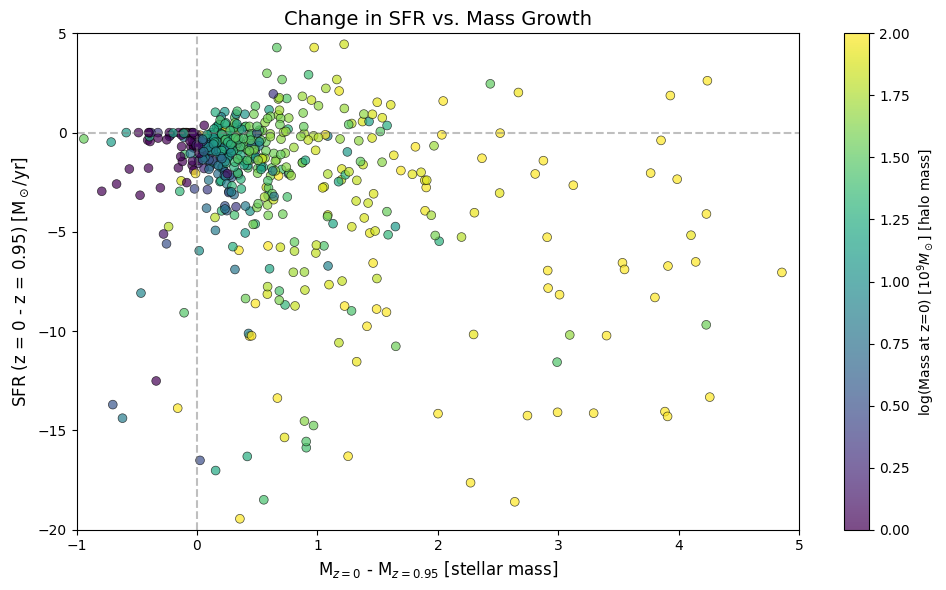

In [177]:
# Plot delta mass vs. delta sfr
fig, ax = plt.subplots(figsize=(10, 6))
valid = ~np.isnan(delta_mass) & ~np.isinf(delta_mass) & ~np.isnan(delta_sfr) & ~np.isinf(delta_sfr)
s= ax.scatter(delta_mass[valid], delta_sfr[valid], s=40,
               alpha=0.7, edgecolors='k', linewidths=0.5, c = np.log10(mass_z0[valid]), 
               cmap='viridis', vmin=0, vmax=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('M$_{z=0}$ - M$_{z=0.95}$ [stellar mass]', fontsize=12)
ax.set_ylabel('SFR (z = 0 - z = 0.95) [M$_\odot$/yr]', fontsize=12)   
ax.set_title('Change in SFR vs. Mass Growth', fontsize=14)
plt.colorbar(s, label='log(Mass at z=0) [$10^9 M_\odot$] [halo mass]')
ax.set_ylim(-20, 5)
ax.set_xlim(-1, 5)
plt.tight_layout()
plt.show()

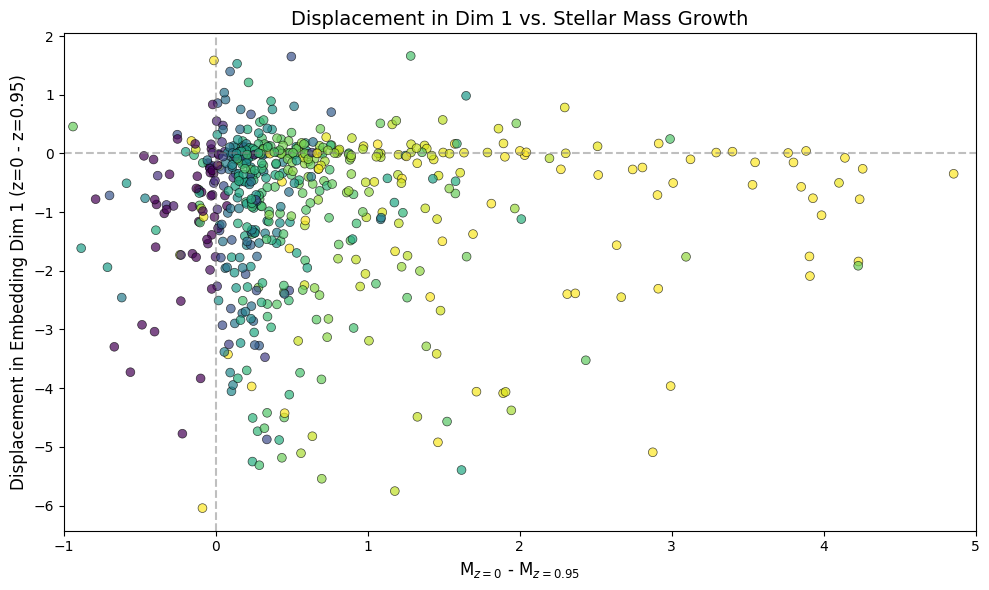

In [178]:
# plot displacement in dim 1 vs. change in stellar mass
fig, ax = plt.subplots(figsize=(10, 6))
valid = ~np.isnan(delta_mass) & ~np.isinf(delta_mass)
ax.scatter(delta_mass[valid], displacement[:, 0][valid], 
           s=40, alpha=0.7, edgecolors='k', linewidths=0.5, c = np.log10(mass_z0[valid]), cmap='viridis', vmin=0, vmax=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('M$_{z=0}$ - M$_{z=0.95}$', fontsize=12)
ax.set_ylabel('Displacement in Embedding Dim 1 (z=0 - z=0.95)', fontsize=12)
ax.set_title('Displacement in Dim 1 vs. Stellar Mass Growth', fontsize=14)
ax.set_xlim(-1, 5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_74847/760658594.py:4: RuntimeWarning: divide by zero encountered in log10
  log_sfr = np.log10(sfr_z095[valid])


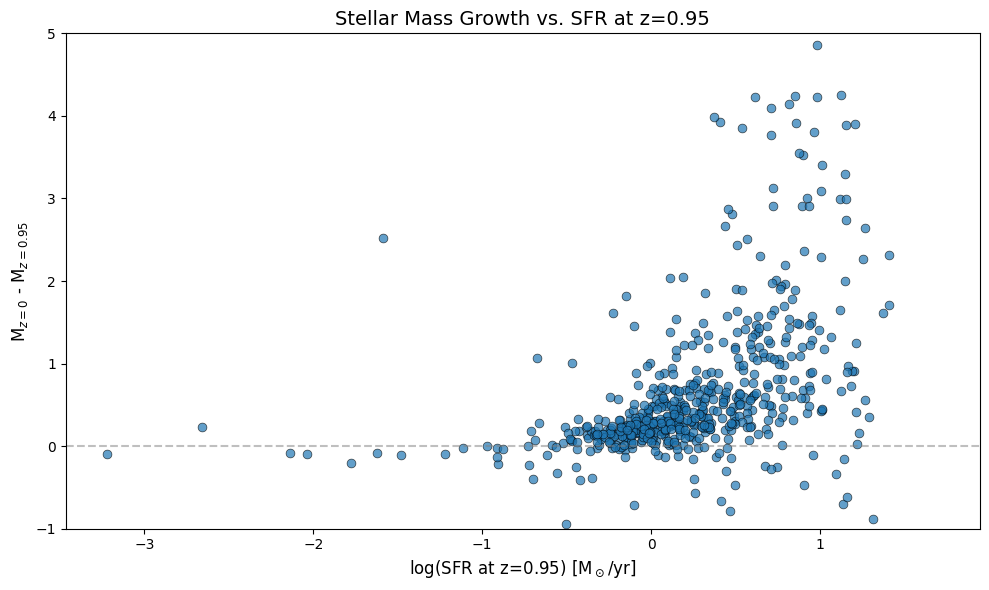

In [191]:
# plot change in stellar mass vs. sfr at z = 0.95
fig, ax = plt.subplots(figsize=(10, 6))
valid = ~np.isnan(delta_mass) & ~np.isinf(delta_mass) & ~np.isnan(sfr_z095) & ~np.isinf(sfr_z095)
log_sfr = np.log10(sfr_z095[valid])
ax.scatter(log_sfr, delta_mass[valid], s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('log(SFR at z=0.95) [M$_\odot$/yr]', fontsize=12)
ax.set_ylabel('M$_{z=0}$ - M$_{z=0.95}$', fontsize=12)   
ax.set_title('Stellar Mass Growth vs. SFR at z=0.95', fontsize=14)
ax.set_ylim(-1, 5)
plt.tight_layout()
plt.show()

## Compare: Is there a systematic shift?

With Nyström projection, we can now ask: do z=0.95 galaxies systematically project to a different region than their z=0 descendants?

In [129]:
# Test for systematic shift
from scipy import stats

print("Testing for systematic displacement (paired t-test):")
print("H0: mean displacement = 0")
print()

for dim in range(3):
    t_stat, p_value = stats.ttest_1samp(displacement[:, dim], 0)
    mean_disp = displacement[:, dim].mean()
    sem = displacement[:, dim].std() / np.sqrt(len(displacement))
    
    print(f"Dim {dim+1}: mean = {mean_disp:.4f} ± {sem:.4f}, t = {t_stat:.2f}, p = {p_value:.4f}")
    if p_value < 0.05:
        direction = "positive" if mean_disp > 0 else "negative"
        print(f"         → Significant {direction} shift (p < 0.05)")
    print()

Testing for systematic displacement (paired t-test):
H0: mean displacement = 0

Dim 1: mean = -0.9361 ± 0.0546, t = -17.15, p = 0.0000
         → Significant negative shift (p < 0.05)

Dim 2: mean = -0.1524 ± 0.0529, t = -2.88, p = 0.0041
         → Significant negative shift (p < 0.05)

Dim 3: mean = -0.0029 ± 0.0444, t = -0.07, p = 0.9474



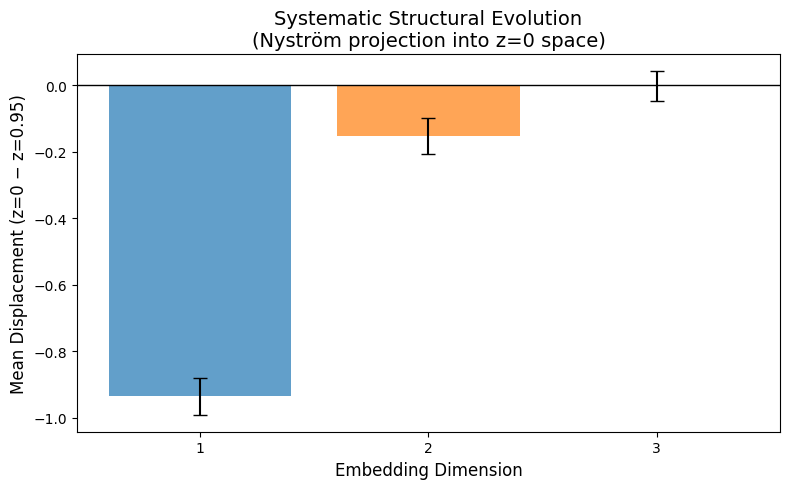

In [130]:
# Summary visualization: mean displacement with error bars
fig, ax = plt.subplots(figsize=(8, 5))

dims = [1, 2, 3]
means = [displacement[:, i].mean() for i in range(3)]
sems = [displacement[:, i].std() / np.sqrt(len(displacement)) for i in range(3)]

ax.bar(dims, means, yerr=sems, capsize=5, color=['tab:blue', 'tab:orange', 'tab:green'], alpha=0.7)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Embedding Dimension', fontsize=12)
ax.set_ylabel('Mean Displacement (z=0 − z=0.95)', fontsize=12)
ax.set_title('Systematic Structural Evolution\n(Nyström projection into z=0 space)', fontsize=14)
ax.set_xticks(dims)

plt.tight_layout()
plt.show()